In [1]:
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import scipy.cluster.hierarchy as hierarchy
from scipy.spatial.distance import pdist, squareform
import sys
import importlib

# python source path
sys.path.append('../Src/')

# custom python 
import zscore_anomaly
import hierarchy_clustering
import utils
import plot

# Create a dictionary of versions
versions = {
    "Python": sys.version.split()[0],
    "Pandas": pd.__version__,
    "NumPy": np.__version__,
    "Scipy": scipy.__version__
}

# Display as a clean DataFrame
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)

# display all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
# Remove scientific notation
np.set_printoptions(suppress=True, precision=4, linewidth=100)
# reset options
# pd.reset_option('display.max_columns')

# Use a single Arrow string & int64 type instance to save memory
arrow_string = pd.ArrowDtype(pa.string())
arrow_int64 = pd.ArrowDtype(pa.int64())
arrow_bool = pd.ArrowDtype(pa.bool8())

  Library Version
0  Python  3.13.9
1  Pandas   2.3.3
2   NumPy   2.3.4
3   Scipy  1.16.3


In [2]:
# Read Arrow IPC file
with open('../Data/crime_data.arrow', 'rb') as f:
    reader = ipc.open_file(f)
    table = reader.read_all()
    
# Convert back to pandas (Arrow‑backed)
df = table.to_pandas(types_mapper=pd.ArrowDtype)
# Display
df.head()

,date,description,location_description,arrest,domestic,beat,district,ward,community_code,year,zip_code,zip_code_area,neighborhood,neighborhood_area,community_name,community_area,month,day_of_week,quarter,year_quarter,time_of_day,fbi_code_desc,fbi_index_code,district_location,sector
0,2001-12-30 02:30:00,AUTOMOBILE,STREET,0,0,334,003,07,43,2001,60649,80526075.8505,South Shore,81812716.3904,South Shore,81812716.3958,December,Sunday,Q4,2001-Q4,Late Night,Motor Vehicle Theft,1,Grand Crossing,1
1,2001-12-24 12:30:00,FRAUD OR CONFIDENCE GAME,APARTMENT,0,0,2313,019,46,03,2001,60640,77305245.6358,Uptown,65095642.836,Uptown,65095642.7289,December,Monday,Q4,2001-Q4,Afternoon,Fraud,0,Town Hall,3
2,2001-12-31 23:00:00,FINANCIAL ID THEFT:$300 &UNDER,APARTMENT,0,0,1531,015,37,25,2001,60651,99039621.5713,Austin,170037750.826,Austin,199254203.427,December,Monday,Q4,2001-Q4,Night,Larceny – Theft,1,Austin,4
3,2001-12-23 22:30:00,AUTOMOBILE,STREET,0,0,1022,010,12,30,2001,60623,155285530.844,Little Village,127998297.819,South Lawndale,127998297.867,December,Sunday,Q4,2001-Q4,Night,Motor Vehicle Theft,1,Ogden,4
4,2001-12-31 20:00:00,PREDATORY,APARTMENT,0,0,1723,017,33,14,2001,60625,105830918.044,Albany Park,53542230.819,Albany Park,53542230.8191,December,Monday,Q4,2001-Q4,Night,Criminal Sexual Assault,1,Albany Park,5


In [3]:
# NaNs
utils.any_nans(df)

--- Missing Values Found (Total Rows: 8,469,872) ---
                       Count Percentage
neighborhood_area     116237    1.3724%
community_area        116237    1.3724%
zip_code_area         116181    1.3717%
ward                   84100    0.9929%
location_description   15338    0.1811%
community_code          9744    0.1150%
zip_code                9744    0.1150%
neighborhood            9744    0.1150%
community_name          9744    0.1150%
district                 139    0.0016%
district_location        139    0.0016%
sector                   139    0.0016%


#### Calculating the Z-score highlights specialized anomalies
- A Z-score of 3.0
    - The value is higher than about 99.87% of all values in a normal distribution 
    - It’s an extreme outlier
- A Z‑score of 2 means:
    - The value is higher than about 97.7% of all values in a normal distribution
    - That year’s count is significantly higher than the historical average
- A Z-score of -1:
    - The value is lower than about 84% of all values
    - It’s a mild decrease, not extreme

##### User Function(s)

In [4]:
def heat_map(data: pd.DataFrame, typ: str='Indexed', figsize: tuple=(16, 6)) -> None:
    # Create the Heatmap
    plt.figure(figsize=figsize)
    sns. heatmap(
        data,
        cmap="RdBu_r",          # Red for high Z-scores, Blue for low
        center=0,               # White represents the mean
        annot=True,             # Change to False if you don't want to see the numbers
        fmt=".2f",              # format as integers
        annot_kws={"size": 8}, # change font size here
        linewidths=.5
    )
    plt.title(f"Z‑Score Heatmap ({typ} Crimes)", fontsize=16)
    plt.xlabel("Year", fontsize=10)
    plt.ylabel("Crime Type", fontsize=12)
    plt.yticks(fontsize=10, rotation=0, ha='right')
    plt.xticks(fontsize=10, rotation=45, ha='right')
    plt.show()

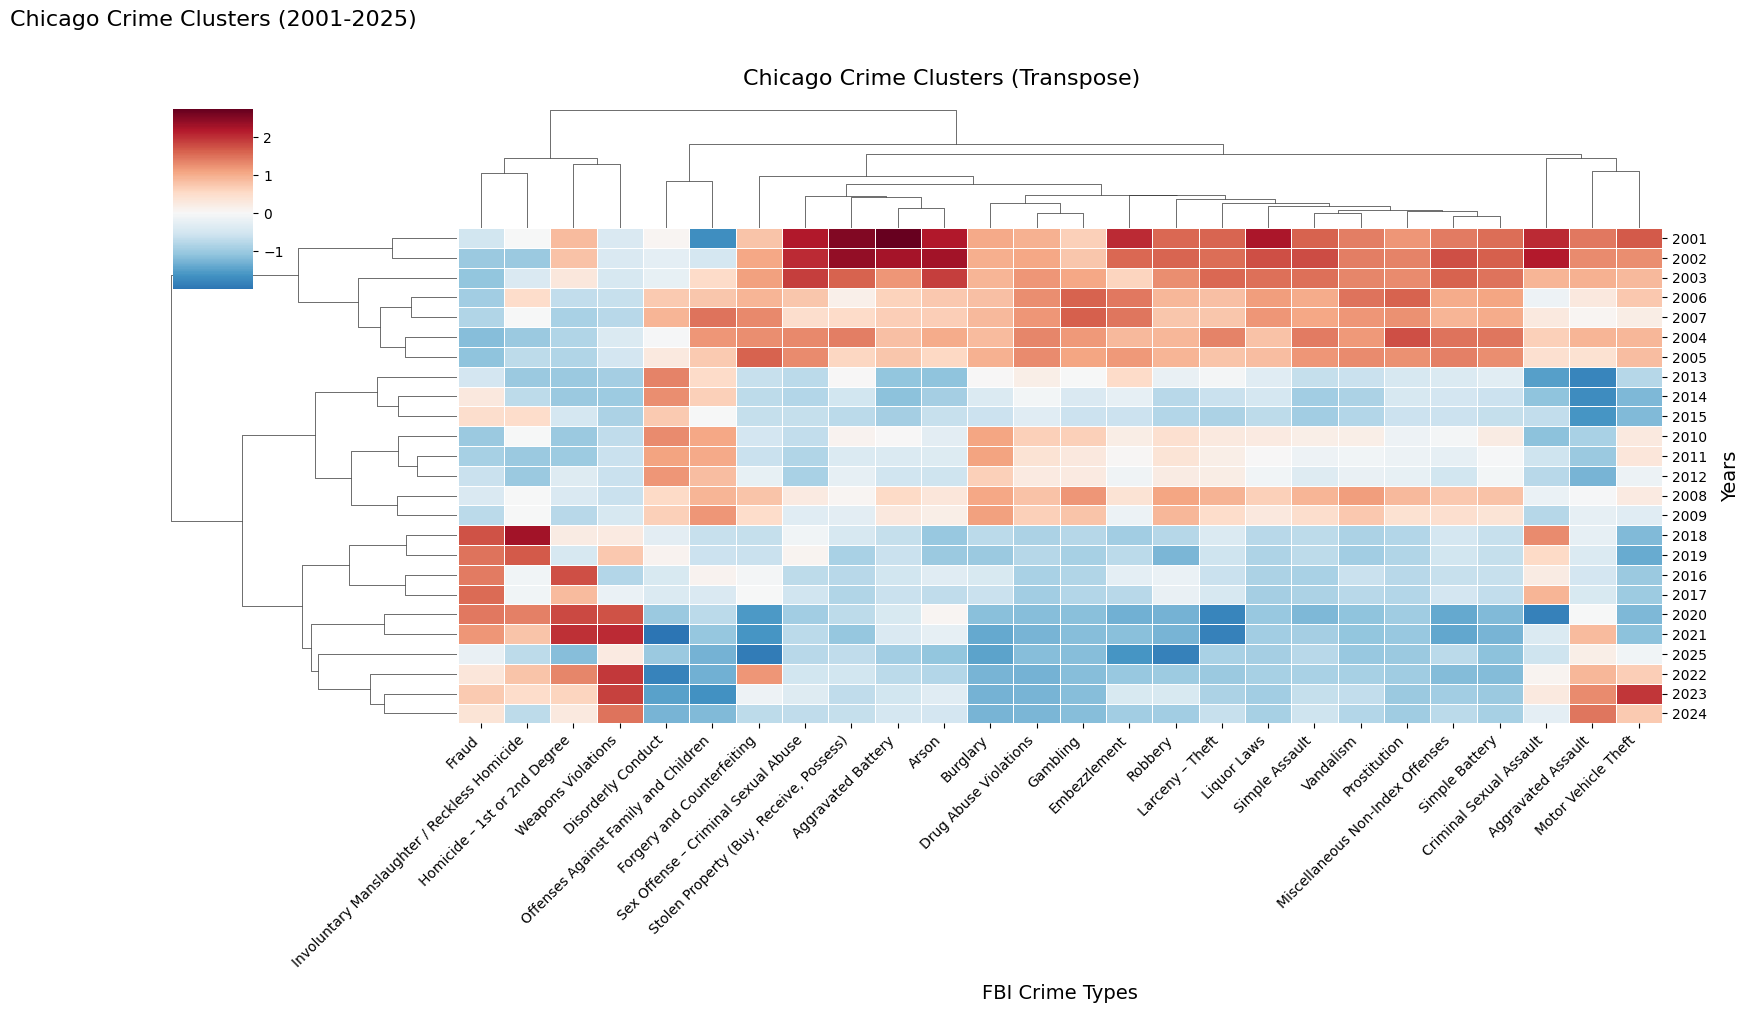

In [31]:
# Z score
z_df = zscore_anomaly.zscore_anomaly(data=df, time_col='year', category_col='fbi_code_desc')

# Create the clustermap
g = sns.clustermap(
    z_df.T, 
    cmap="RdBu_r", 
    center=0, 
    figsize=(16, 10),
    # row_cluster=True,  # Keep years in chronological order (on the Y-axis)
    col_cluster=True,  # Cluster the crimes together (on the X-axis)
    linewidths=0.5,
    xticklabels=True,   # Ensure all crime names show up
    yticklabels=True    # Ensure all years show up
)

# Rotate X-axis labels for readability
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
plt.title("Chicago Crime Clusters (2001-2025)", fontsize=16, pad=60)
plt.suptitle("Chicago Crime Clusters (Transpose)", fontsize=16, y=1.02)
g.ax_heatmap.set_xlabel('FBI Crime Types', fontsize=14, labelpad=10)
g.ax_heatmap.set_ylabel('Years', fontsize=14, labelpad=10)

# Save the figure with high resolution and tight cropping
plt.savefig("../Image/cluster_Heatmap_analysis.png", dpi=1200, bbox_inches='tight')
plt.show()

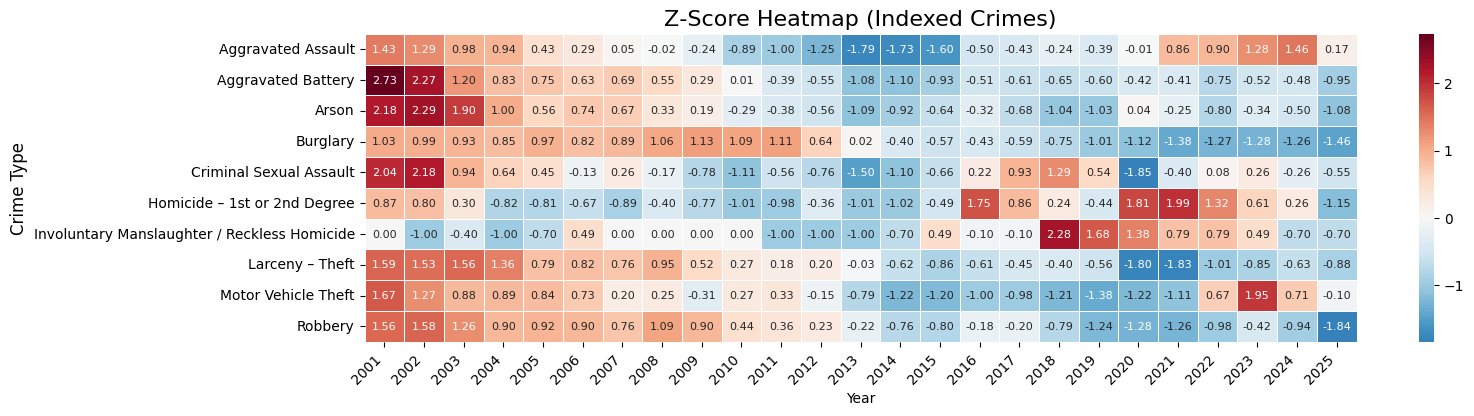

In [32]:
# Calculate z-scores Indexed Crime
df.fbi_index_code = df.fbi_index_code.astype('bool')
mask = df.fbi_index_code == True
z_df_i = zscore_anomaly.zscore_anomaly(data=df[mask], time_col='year', category_col='fbi_code_desc')
# plot
heat_map(z_df_i, 'Indexed', (16,4))

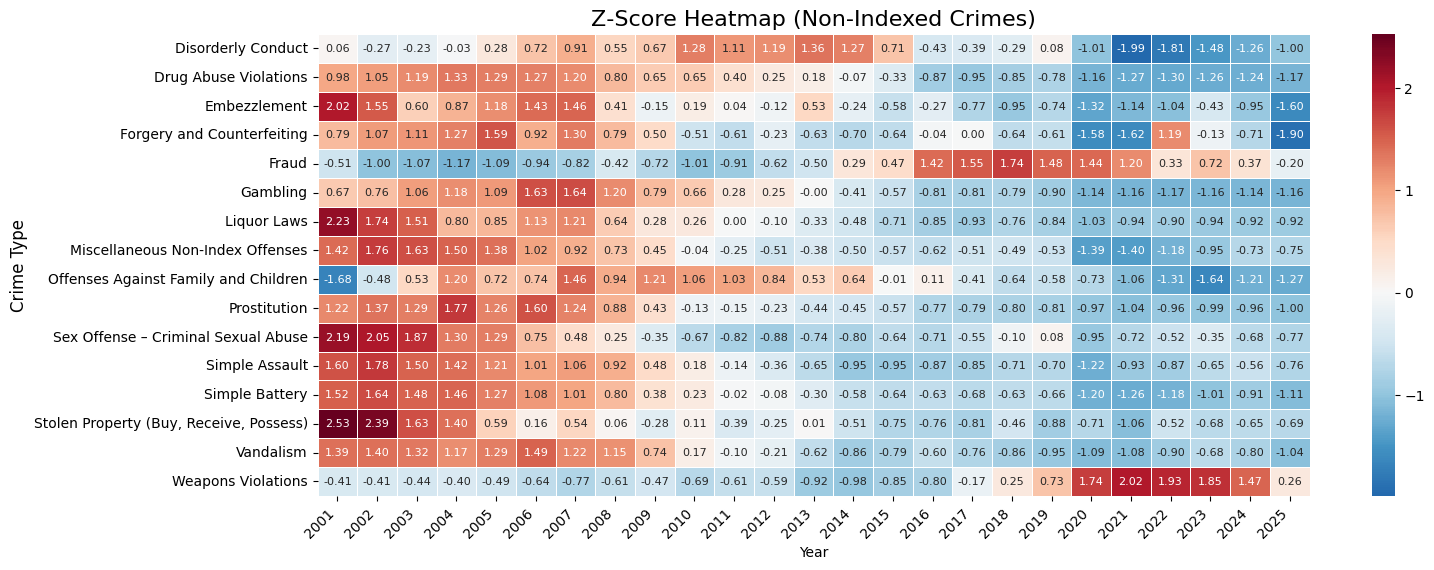

In [33]:
# Calculate z-scores Non-Indexed Crime
mask = df.fbi_index_code == False
z_df_n = zscore_anomaly.zscore_anomaly(data=df[mask],time_col='year', category_col='fbi_code_desc')
heat_map(z_df_n, 'Non-Indexed')

**Note:**
1. The Color Intensity (The Values)
* Since you are using Z-scores, look at the color first:
  - Deep Red: The crime count for that specific year was significantly above its historical average.
    - Deep Blue: The crime count for that specific year was significantly below its historical average.
    - White/Light Colors: The crime count was "normal" or very close to the 25-year mean.

2. The Dendrogram (The "Tree" Structure)
* The branches on the top (or side) tell you how similar items are.
* Close Neighbors: If two crime types are connected by a short "U-shaped" branch, they have very similar patterns over the 25-year period.
* Branch Length: The longer the vertical lines of the branch before they join, the less similar those two groups are.

3. Reading the "Clusters" (The Groups)
*  The "Legacy" Cluster: Crimes that were rampant in the early 2000s but have since crashed (like Drug Abuse Violations or Prostitution). These will be Red on the top-left and deep Blue on the bottom-right.
* The "Resilient" Cluster: Crimes that have stayed consistently high or "Red" for almost the entire 25 years. These are the persistent issues Chicago faces.
* The "Modern Surge" Cluster: Crimes that were blue for years but have recently turned bright Red (like Motor Vehicle Theft and Weapons Violations).

4. Reading the X and Y Axis Together
* To find a specific "Anomaly," look for a single "pop" of color that breaks a trend.
* Vertical Red Streaks: If you see a vertical column of red across many crimes for a single year (like 2020), it suggests an External Event (like the Pandemic or civil unrest) affected almost everything at once.
* Horizontal Red Streaks: If one crime type is red across many years, it shows a long-term sustained increase for that specific category.

5. Why the "Rotation" Helps
* By rotating the plot, you can now scan horizontally to see which crimes behave similarly in the same year, and scan vertically to see how a single crime's "fortune" has changed from 2001 to 2025.

**Tip: The "Pivot Point"**
* Look for where the colors flip from Blue to Red. In Chicago's data, there is often a "pivot" around 2016 and 2020. These are the years where the "old" patterns of crime significantly shifted into the "modern" patterns we see today.

### Clustering

In [9]:
z_df.head()

year,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
fbi_code_desc,,,,,,,,,,,,,,,,,,,,,,,,,
Disorderly Conduct,0.056858,-0.271316,-0.226084,-0.027832,0.279169,0.721867,0.913381,0.546712,0.667973,1.281013,1.105859,1.187661,1.364741,1.265615,0.713205,-0.432034,-0.392577,-0.290564,0.080917,-1.009466,-1.988213,-1.807284,-1.476223,-1.263536,-0.999842
Drug Abuse Violations,0.981619,1.050354,1.192205,1.333854,1.291757,1.271565,1.203283,0.802304,0.653404,0.646052,0.404649,0.248145,0.179460,-0.072769,-0.333408,-0.867425,-0.950260,-0.854686,-0.779354,-1.161399,-1.266239,-1.299272,-1.264477,-1.238191,-1.171168
Embezzlement,2.018299,1.554251,0.595219,0.873648,1.183013,1.430505,1.461442,0.409600,-0.147258,0.193044,0.038361,-0.116321,0.533346,-0.240067,-0.580369,-0.271004,-0.765989,-0.951608,-0.735052,-1.322846,-1.137227,-1.044417,-0.425687,-0.951608,-1.601275
Forgery and Counterfeiting,0.786856,1.067876,1.113795,1.273590,1.591345,0.920938,1.304815,0.788693,0.498489,-0.511714,-0.612734,-0.227020,-0.625591,-0.699060,-0.643958,-0.043347,0.002571,-0.642122,-0.607224,-1.580692,-1.615590,1.194611,-0.127837,-0.708244,-1.898447
Fraud,-0.514709,-1.003537,-1.074824,-1.174844,-1.093009,-0.941342,-0.824227,-0.415416,-0.720570,-1.012266,-0.914791,-0.616548,-0.497615,0.289092,0.470584,1.420597,1.552624,1.735934,1.483882,1.436600,1.199097,0.330919,0.718998,0.365835,-0.200463


### Hierarchical Clustering Linkage Methods
* In hierarchical clustering, choosing the right linkage method is just as important as choosing the distance metric (like Euclidean or Manhattan). The linkage determines the "shape" of the clusters and the algorithm's sensitivity to outliers. These linkage methods work in practice; we need to examine the step-by-step logic of the Agglomerative (Bottom-Up) algorithm. This is the most common way hierarchical clustering is implemented.
* Agglomerative (Bottom-Up) Hierarchical Clustering is a widely used unsupervised machine learning algorithm that builds a nested hierarchy of clusters by iteratively merging the closest pairs of data points. Unlike k-means, it does not require specifying the number of clusters in advance, and the results are often visualized as a dendrogram. 
* `Linkage method choice:` The choice of linkage method in hierarchical clustering is a foundational decision that directly dictates how distances between clusters are calculated, which subsequently defines the structure and quality of the final clustering. 
    * cluster shape
    * sensitivity to noise
    * chaining vs. compactness
    * dendrogram height structure
    * number of clusters detected
#### 1. Specifying the Linkage Criterion: Linkage methods dictate how the algorithm decides which clusters to merge at each step.
[scipy.cluster.hierarchy.linkage](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html)

#### 2. Specifying the Distance Metric: The distance metric defines the "proximity" between two single observations in your dataset.
[scipy.spatial.distance.cdist](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.cdist.html)

##### User Function(s)

In [14]:
def plot_clustering(data: pd.DataFrame,  method: str, metric: str='euclidean', 
                    figsize: tuple=(8,4), rotation: int='45') -> None:
    # Hierarchical clustering (indexed): linkage matrix
    Z = hierarchy.linkage(data.values, method=method, metric=metric, optimal_ordering=True)
    plt.figure(figsize=figsize)
    hierarchy.dendrogram(Z, labels=data.index.tolist(), leaf_rotation=rotation)
    # Fix alignment
    for lbl in plt.gca().get_xticklabels(): 
        lbl.set_ha('right')
    plt.title(f'Linkage: ({method.capitalize()})')
    plt.ylabel('Distance')
    plt.show()

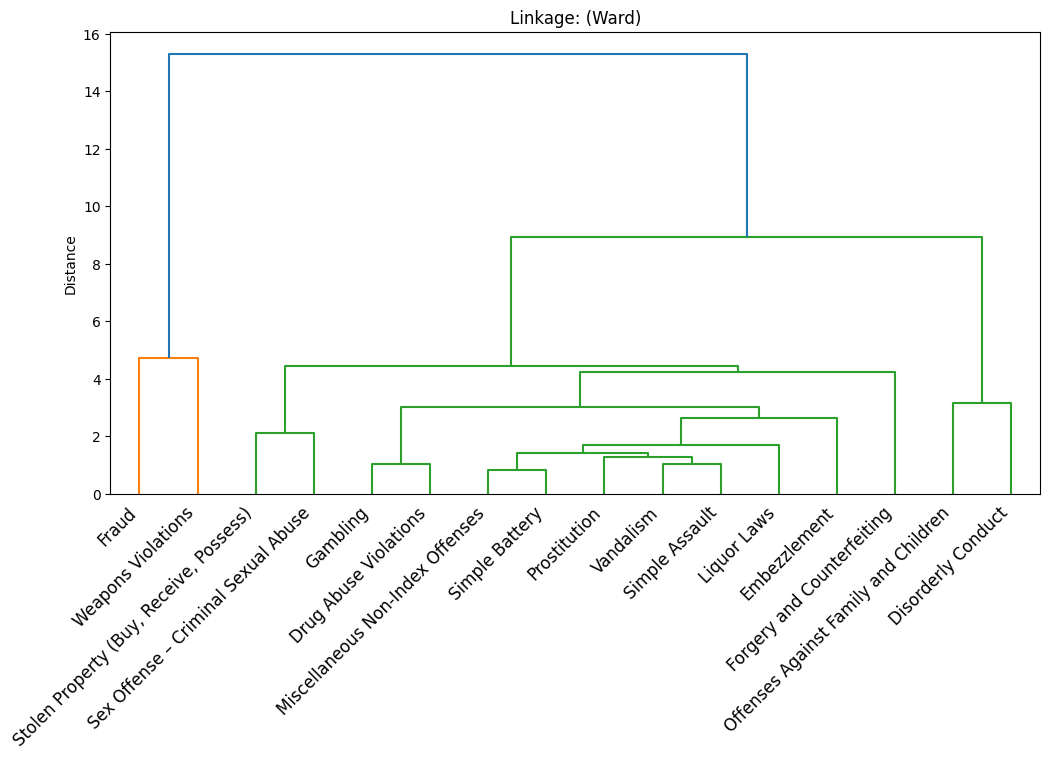

In [23]:
# Initialize Linkage variable
methods = ['ward', 'single', 'complete', 'average', 'median', 'centroid']
# plot
plot_clustering(z_df,  method='ward', metric='euclidean', figsize=(12,6), rotation=45)

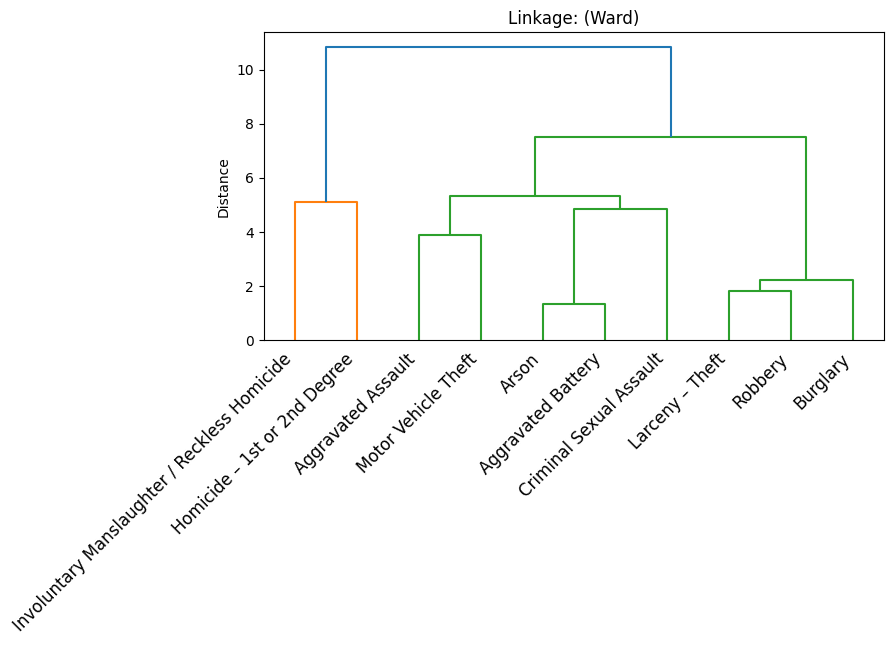

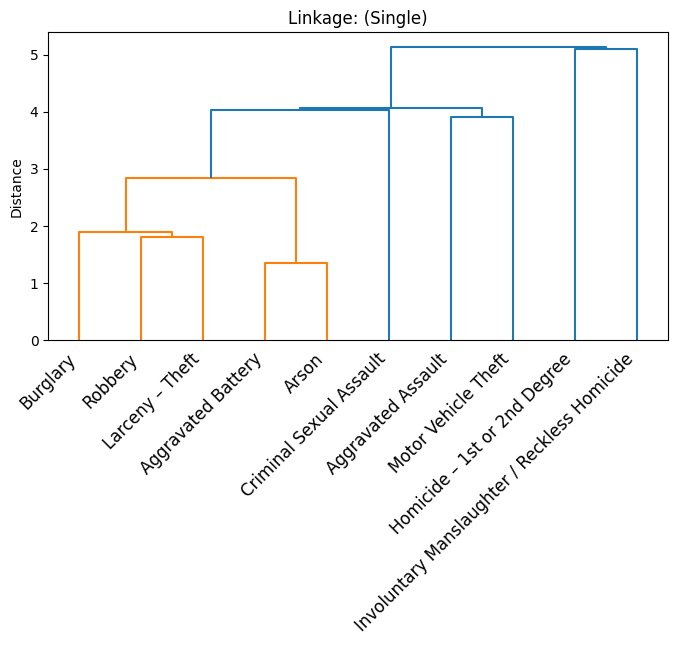

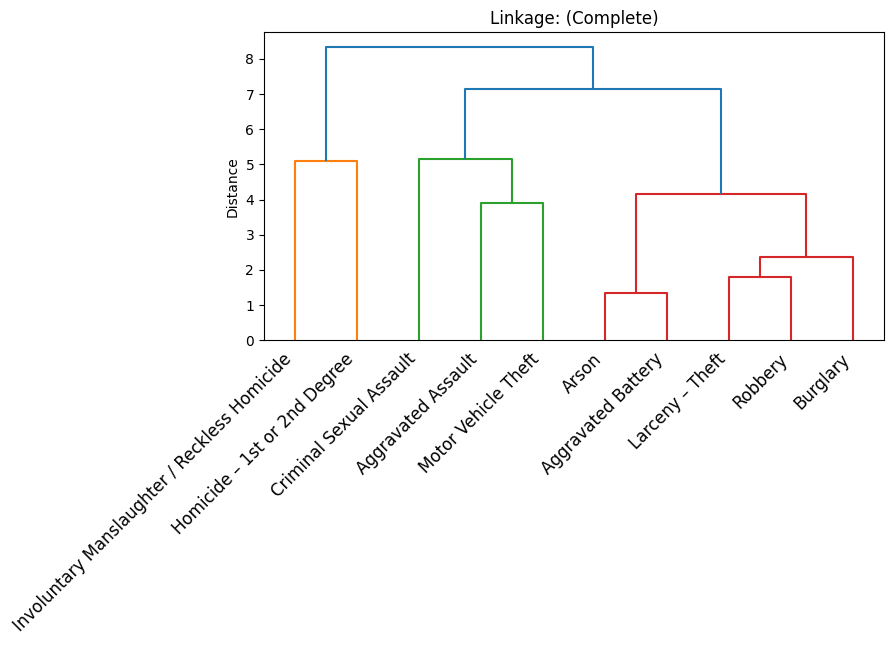

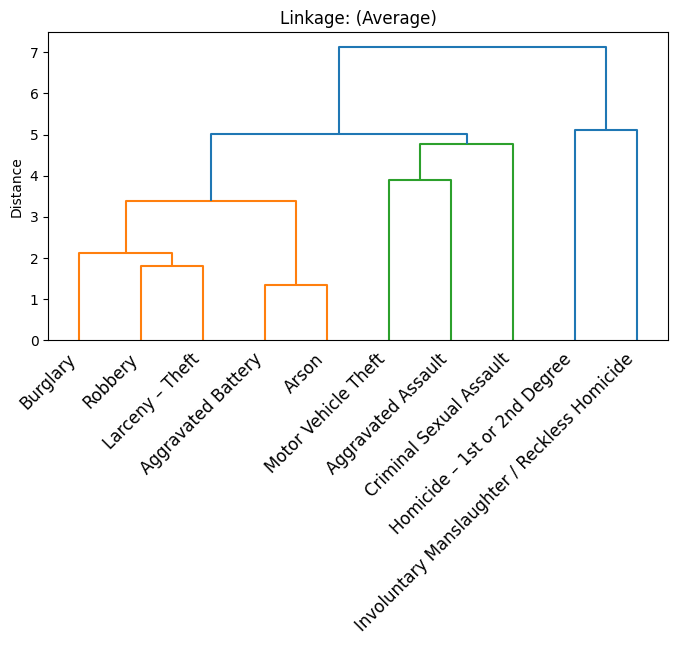

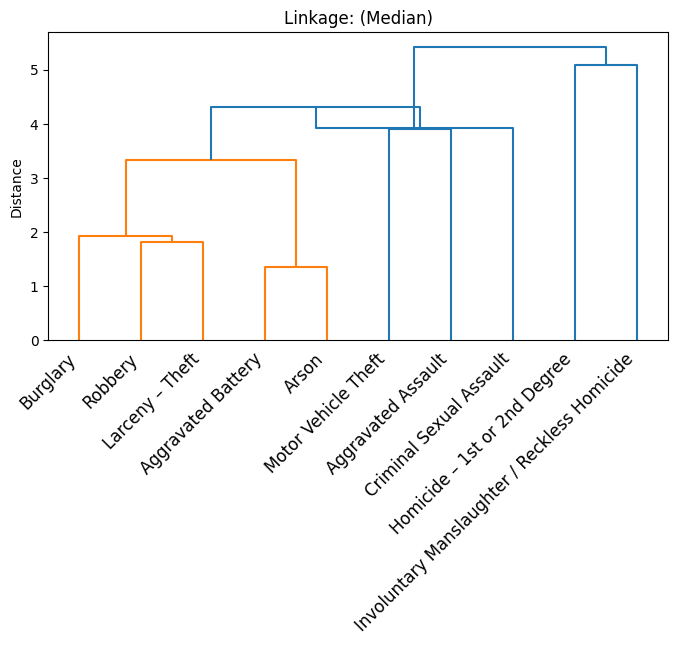

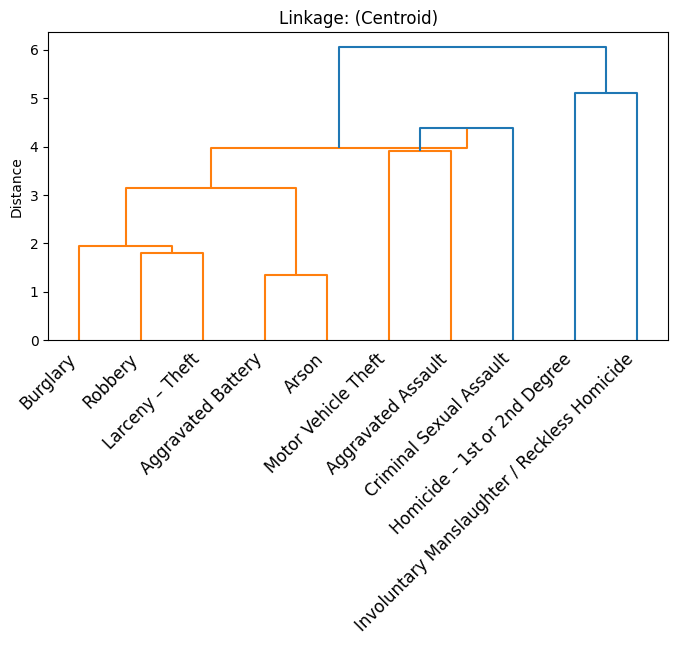

In [50]:


# iterate
for method in methods:
    # Hierarchical clustering (indexed)
    Z_i = hierarchy.linkage(z_df_i.values, method=method, metric='euclidean', optimal_ordering=True)
    plt.figure(figsize=(8,4))
    hierarchy.dendrogram(Z_i, labels=z_df_i.index.tolist(), leaf_rotation=45)
    # Fix alignment
    for lbl in plt.gca().get_xticklabels(): 
        lbl.set_ha('right')
    plt.title(f'Linkage: ({method.capitalize()})')
    plt.ylabel('Distance')
    plt.show()






1. Specifying the Distance Metric
    * The distance metric defines the "proximity" between two single observations in your dataset. 
        * **Euclidean Distance:** The most common metric, measuring the straight-line distance between points.
        * **Manhattan Distance:** The sum of absolute differences between coordinates (useful for high-dimensional or grid-based data).
        * **Cosine Similarity:** Measures the angle between vectors, often used in text analysis to compare document similarity.
        * **Mahalanobis Distance:** Accounts for correlations between variables and is useful for detecting outliers.
2. Specifying the Linkage Criterion
    * Linkage methods dictate how the algorithm decides which clusters to merge at each step. 
        * **Single Linkage (Nearest Neighbor):** Uses the minimum distance between any point in one cluster and any point in another. It can handle non-spherical shapes but is prone to "chaining," in which clusters are linked by a single intermediate point.
    * **Complete Linkage (Farthest Neighbor):** Uses the maximum distance between points in two clusters. This results in more compact, spherical clusters.
    * **Average Linkage (UPGMA):** Calculates the average distance between all pairs of points across two clusters, providing a balance between single and complete linkage.
    * **Centroid Linkage:** Measures the distance between the geometric centers (centroids) of two clusters.
    * **Ward’s Method:** Minimizes the increase in total within-cluster variance after merging. It is highly effective for creating clusters of similar size and density.

#### Single Linkage (Nearest Neighbor):
* Single linkage is an agglomerative hierarchical clustering method that defines the distance between two clusters as the minimum distance between any pair of points, one from each cluster. At each iteration, the two clusters with the smallest such distance are merged.

Pros: Can identify non-elliptical, elongated cluster shapes.
Cons: Prone to chaining, where clusters are joined together simply because they are linked by a series of intermediate points, even if the ends of the chain are very different. 
2. Complete Linkage (Farthest Neighbor)
This method defines the distance between two clusters as the maximum distance between any single point in the first cluster and any single point in the second cluster. 
Pros: Produces more compact, "spherical" clusters with similar diameters.
Cons: Highly sensitive to outliers, as a single point far away can drastically increase the distance between clusters. 
3. Average Linkage (UPGMA)
This method calculates the average distance between all pairs of points across the two clusters. 

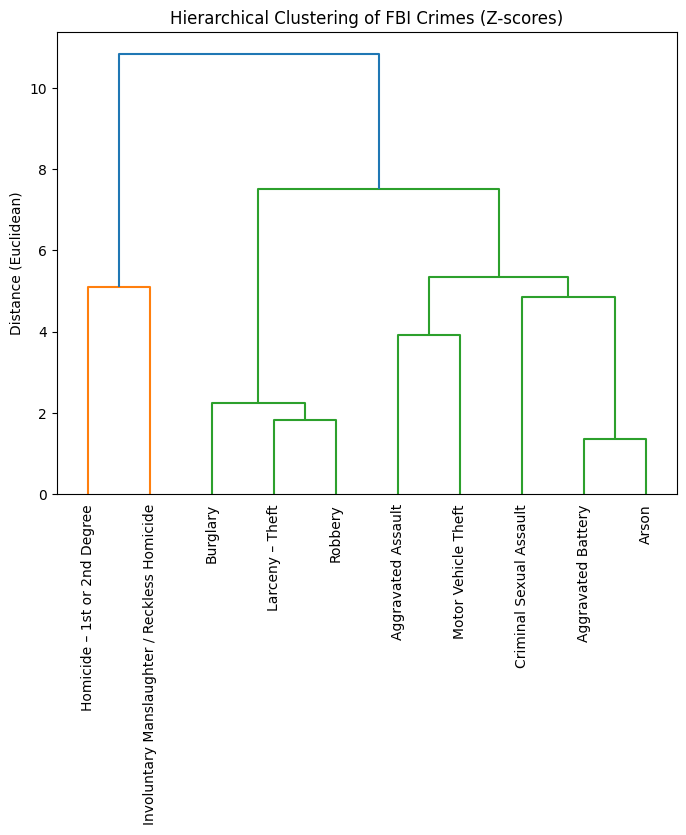

In [52]:
# Hierarchical clustering (indexed)
Z_i = hierarchy.linkage(z_df_i.values, method='ward', metric='euclidean')

# Plot dendrogram with crime names
plt.figure(figsize=(8,6))
hierarchy.dendrogram(Z_i, labels=z_df_i.index.tolist(), leaf_rotation=90, leaf_font_size=10)
plt.title("Hierarchical Clustering of FBI Crimes (Z-scores)")
plt.ylabel("Distance (Euclidean)")
plt.show()

In hierarchical clustering algorithms, `Z (Linkage Matrix)` and `I (Inconsistency Coefficient)` are key components used to construct, represent, and analyze the hierarchical structure of data, particularly when using agglomerative methods.
1. **$Z$ (Linkage Matrix)** <br>The linkage matrix, often denoted as `Z`, is the core output of an agglomerative hierarchical clustering
* **Definition:** It is an $(n-1)\times 4$ matrix where $n$ is the number of data points. Each row represents a merging step (a node in the dendrogram).
* **Structure:**
  * **Columns 1 & 2:** Indicate which clusters/points were merged to form a new cluster.
  * **Column 3:** Represents the distance (height) between the two clusters that were merged.
  * **Column 4:** Indicates the number of original data points in the newly formed cluster.
* **Purpose:** <br> It maps the entire hierarchy of how individual data points are merged into larger clusters until all points form one single group. <br> `Z` tells you the "height" at which nodes are joined. If the distance in Column 3 jumps significantly between one step and the next, it suggests that you are forcing two very different groups together.
* **Linkage Methods (determining "distance"):** <br> The method used to calculate distances between clusters (the values in Column 3) significantly impacts the structure:
    * Single Linkage: Minimum distance between points in clusters.
    * Complete Linkage: Maximum distance between points in clusters.
    * Average Linkage: Average distance between all pairs of points.
    * Ward’s Method: Minimizes the total within-cluster variance.
2. **$I$ (The Inconsistency Coefficient)** <br> The `Inconsistency Coefficient` is a metric used to determine if a specific merge in the dendrogram is "natural" or "forced." It compares the height of a link to the average heights of the links below it. <br> Think of it like a family tree. If most generations have children at age 25, but one generation suddenly has a child at age 80, that 80-year gap is "inconsistent" with the rest of the tree.
* For a specific merge, the inconsistency
    * $I$ is calculated as: $I = \frac{h-\mu}{\sigma}$
    * $h$: The height (distance) of the current merge.
    * $\mu$: The average height of all links included in the calculation (the current link and its ancestors up to a certain depth)
    * $\sigma$: The standard deviation of those heights.
* **Low Inconsistency:** $\approx$ 0: The merge is consistent with the merges below it. The points are likely part of the same natural cluster
* **High Inconsistency:** The merge distance is much larger than previous merges. This is often where you should "cut" the tree to define your final clusters

In [15]:
Z_matrix = hierarchy.linkage(z_df_i, method='ward')

In [16]:
# Linkage Matrix & Inconsistency coefficient matrix
n_clusters_i = hierarchy_clustering.choose_clusters_from_inconsistency(Z_matrix)
n_clusters_l = hierarchy_clustering.choose_clusters_from_linkage(Z_matrix)

----- Using Inconsistency coefficient Matrix ------
Recommended number of clusters: 4
Jump occurred at merge index 5

----- Using Linkage Matrix -----
Recommended clusters: 3
Jump at merge index: 6



In [17]:
# Get distance for 3 clusters
k = 4
# Distance threshold that yields exactly k clusters
idx = Z_matrix.shape[0] - (k - 1)
distance = int(Z_matrix[idx - 1, 2])
print(f"Distance: {distance}")

Distance: 5


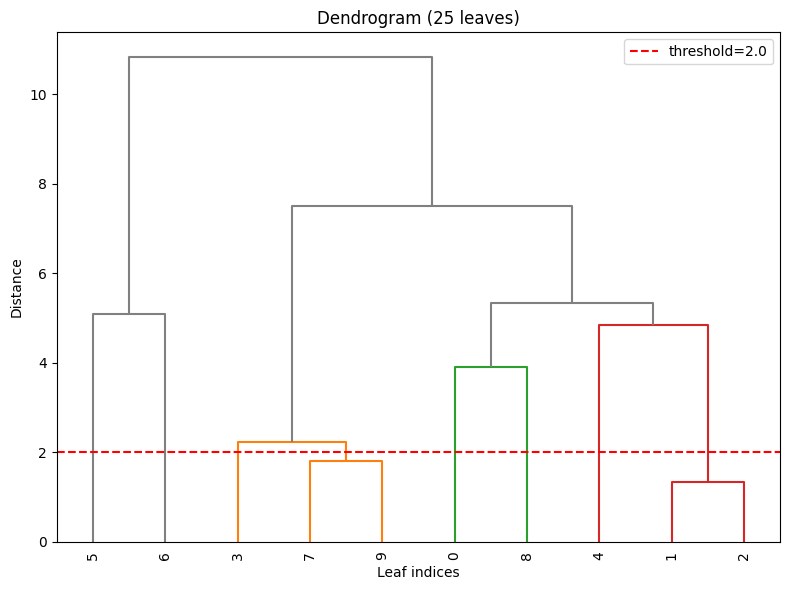

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
dn = hierarchy.dendrogram(Z_matrix, ax=ax, 
                         leaf_rotation=90, leaf_font_size=10,
                         color_threshold=distance, above_threshold_color='gray')
ax.set_title('Dendrogram (25 leaves)')
ax.set_xlabel('Leaf indices')
ax.set_ylabel('Distance')
ax.axhline(y=2.0, color='r', ls='--', label='threshold=2.0')
ax.legend()
plt.tight_layout()
plt.show()

In [29]:
clusters = hierarchy.fcluster(z_df_i, t=distance, criterion='distance')
print("Cluster sizes:", np.unique(clusters, return_counts=True))

ValueError: Linkage matrix 'Z' must have 4 columns.

In [26]:
z_df_i.columns

Index(['2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009',
       '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018',
       '2019', '2020', '2021', '2022', '2023', '2024', '2025'],
      dtype='string[pyarrow]', name='year')

In [27]:
crime_groups = pd.DataFrame({
    'fbi_code_desc': z_df.columns, 
    'cluster_id': clusters
}).sort_values('cluster_id')

ValueError: All arrays must be of the same length

In [16]:
# Create the mapping using .columns instead of .index
# This matches the names on the X-axis of your rotated plot
crime_groups = pd.DataFrame({
    'fbi_code_desc': z_df.columns, 
    'cluster_id': clusters
}).sort_values('cluster_id')

# Display the members
for cluster_num in range(1, (len(np.unique(clusters))) + 1):
    members = crime_groups[crime_groups['cluster_id'] == cluster_num]['fbi_code_desc'].tolist()
    print(f"--- Cluster {cluster_num} & {distance} Distance Calculation value ---")
    print("\n".join([f"  • {m}" for m in members]))
    print("-" * 30)

ValueError: All arrays must be of the same length

In [83]:
# What is the difference between depth of 2 and 3?
I2 = hierarchy.inconsistent(Z_matrix, 2)
I3 = hierarchy.inconsistent(Z_matrix, 3)

print("Max inconsistency:")
print("depth=2:", I2[:,3].max())  
print("depth=3:", I3[:,3].max()) 

Max inconsistency:
depth=2: 1.1295771896800106
depth=3: 1.6715303056222197


- Each row of the inconsistency matrix has four values:
    - Mean of the merge heights in the local neighborhood
    - Standard deviation of those heights
    - Number of links/merges used in the local neighborhood
    - Inconsistency coefficient : 
$
\text{inconsistency}_i = \frac{Z_{[i,2]} - \text{Local mean}}{\text{local Std}}
$


**The fourth column is the one that matters for evaluating cluster stability.**

- 0.0 $\rightarrow$ the merge height is identical to the local average $\rightarrow$ extremely natural merge
- 0.6 – 0.8 $\rightarrow$ mild deviation $\rightarrow$ still natural, but slightly broader merges
- 0.9 – 1.2 $\rightarrow$ noticeable deviation $\rightarrow$ the algorithm is merging groups that are less similar
- $\gt$ 2.0 (not present in your data) $\rightarrow$ strongly unnatural merges $\rightarrow$ forced merges across major cluster boundaries

Last 5 merges in Linkage Matrix (Z):
[[ 3.     24.      4.2377 10.    ]
 [22.     26.      4.4211 12.    ]
 [ 4.     15.      4.729   2.    ]
 [25.     27.      8.931  14.    ]
 [28.     29.     15.3077 16.    ]]

Last 5 rows in Inconsistency Matrix (I):
[Mean, Std Dev, Count, Inconsistency Coefficient]
[[3.628  0.8622 2.     0.7071]
 [3.5878 1.2877 3.     0.6471]
 [4.729  0.     1.     0.    ]
 [5.5049 3.0331 3.     1.1296]
 [9.6559 5.3265 3.     1.0611]]


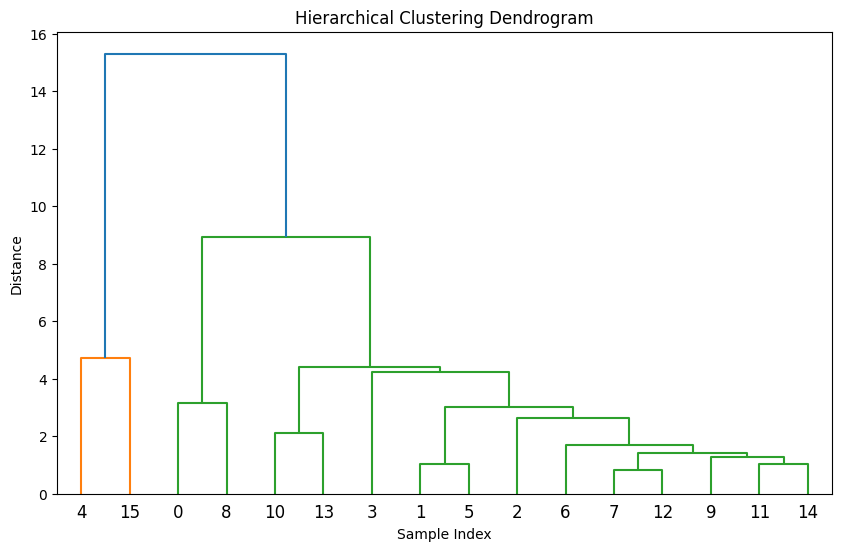

In [84]:
from scipy.cluster.hierarchy import linkage, inconsistent, dendrogram

# linkage & inconsistent
Z_matrix = linkage(z_df, method='ward')
I_matrix = inconsistent(Z_matrix, d=2)

# Display the last 5 merges
print("Last 5 merges in Linkage Matrix (Z):")
print(Z_matrix[-5:])
print("\nLast 5 rows in Inconsistency Matrix (I):")
print("[Mean, Std Dev, Count, Inconsistency Coefficient]")
print(I_matrix[-5:])

# Visualize with a Dendrogram
plt.figure(figsize=(10, 6))
dendrogram(Z_matrix)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

## Determine Number of Cluster

In [85]:
# Last 10 merges (closest to the root)
print("Last 10 inconsistency coefficients:")
print(I_matrix[-10:, -1])


Last 10 inconsistency coefficients:
[0.7071 0.     0.7071 0.7467 0.     0.7071 0.6471 0.     1.1296 1.0611]


In [86]:
# inconsistency coefficients only go up to approximately 1.13
for t in np.linspace(0.1, 1.2, 12):
    labels = fcluster(Z_matrix, t, criterion='inconsistent')
    print(f"t={t:.2f} -> {len(np.unique(labels))} clusters")

t=0.10 -> 10 clusters
t=0.20 -> 10 clusters
t=0.30 -> 10 clusters
t=0.40 -> 10 clusters
t=0.50 -> 10 clusters
t=0.60 -> 10 clusters
t=0.70 -> 10 clusters
t=0.80 -> 3 clusters
t=0.90 -> 3 clusters
t=1.00 -> 3 clusters
t=1.10 -> 3 clusters
t=1.20 -> 1 clusters


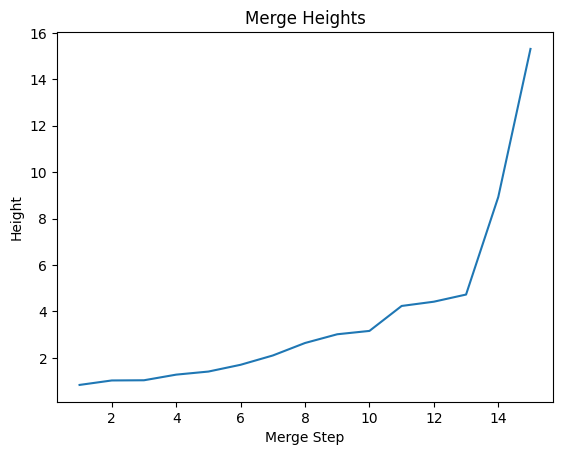

In [87]:
heights = Z_matrix[:, 2]
plt.plot(range(1, len(heights)+1), heights)
plt.title("Merge Heights")
plt.xlabel("Merge Step")
plt.ylabel("Height")
plt.show()

In [88]:
# display last 10 merge heights directly
print(Z_matrix[-10:, 2])

[ 1.704   2.1046  2.6423  3.0183  3.1625  4.2377  4.4211  4.729   8.931  15.3077]


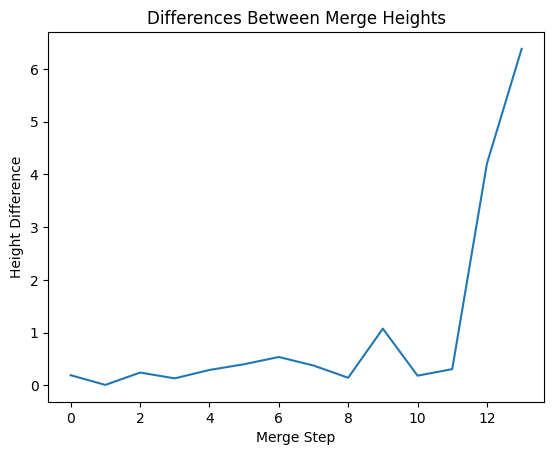

In [89]:
heights = Z_matrix[:, 2]
diffs = np.diff(heights)

plt.plot(diffs)
plt.title("Differences Between Merge Heights")
plt.xlabel("Merge Step")
plt.ylabel("Height Difference")
plt.show()


In [94]:
# Use the transposed DataFrame you used for the plot
# This ensures we are looking at the 26 crime types (columns)


# clusters = fcluster(linkage, t=distance_threshold, criterion='distance')
# clusters = fcluster(linkage, t=distance, criterion='distance')


# Create the mapping using .columns instead of .index
# This matches the names on the X-axis of your rotated plot
crime_groups = pd.DataFrame({
    'fbi_code_desc': z_df.T.columns, 
    'cluster_id': clusters
}).sort_values('cluster_id')

# Display the members
for cluster_num in range(1, (len(np.unique(clusters))) + 1):
    members = crime_groups[crime_groups['cluster_id'] == cluster_num]['fbi_code_desc'].tolist()
    print(f"--- Cluster {cluster_num} & {distance} Distance Calculation value ---")
    print("\n".join([f"  • {m}" for m in members]))
    print("-" * 30)


ValueError: All arrays must be of the same length

In [92]:
# cuts
cuts = distance.copy()
# generate the cluster labels at each cut height
labels = {h: fcluster(Z, t=h, criterion='distance') for h in cuts}

# clusters at each height
print("Clusters @ each hight:" ,{k: len(set(v)) for k, v in labels.items()})

def similarity(a, b):
    return np.mean(a == b)

# score
similarity(labels[3.2], labels[4.3]), similarity(labels[4.3], labels[4.8])

AttributeError: 'int' object has no attribute 'copy'

In [ ]:
# generate the cluster labels at each cut height
labels = {h: fcluster(Z, t=h, criterion='distance') for h in cuts}
labels

In [ ]:
from sklearn.metrics import silhouette_score

# Silhouette score (cluster quality)
scores = {h: silhouette_score(z_score.T, labels[h]) for h in labels}
scores

**Silhouette score for hierarchical clustering on standardized temporal profiles:**
- 0.20–0.30 $\rightarrow$ weak but usable
- 0.30–0.40 $\rightarrow$ moderate, interpretable structure
- 0.40+ $\rightarrow$ strong, rarely seen in noisy real‑world time series

In [ ]:
# Create a list to store dataframes with their threshold ID
centroid_list = []

for h, lab in labels.items():
    # Ensure we are working with Crime as Rows, Years as Columns
    # If your z_score is already (Crimes x Years), don't use .T
    df_tmp = z_score.T.copy() 
    df_tmp['cluster'] = lab
    
    # Calculate means and add the threshold 'h' as a column
    mean_df = df_tmp.groupby('cluster').mean().assign(threshold=h)
    centroid_list.append(mean_df)

# Concatenate into one master DataFrame
df_centroids = pd.concat(centroid_list).reset_index()

# View the result
mask = df_centroids.threshold == 3.2
df_centroids.loc[mask]

# # Inspect cluster centroids
# centroids = {}
# for h, lab in labels.items():
#     df_tmp = pd.DataFrame(z_score.T)
#     df_tmp['cluster'] = lab
#     centroids[h] = df_tmp.groupby('cluster').mean()
# centroids

#### Tranpost Z-Scores

In [ ]:
# Raw Tranpost linkage matrix, and this matrix tells the entire story of your dendrogram’s structure
Z_t = g_t.dendrogram_col.linkage

# Inconsistency coefficient column
I_t = inconsistent(Z_t, 2)   # depth=2 is the standard choice

In [ ]:
# Inspect inconsistency
heights_t = Z_t[:, 2] 
incons_t = I_t[:, 3]

print(heights_t) 
print(incons_t)

In [ ]:
# Find merges with higher inconsistency,
idx_high_t = np.where(incons_t > 1.0)[0]
critical_heights_t = heights_t[idx_high_t]
# Critical_heights are where merges start to be “stretched”.
critical_heights_t

In [ ]:
plot.plot_cuts(heights_t, incons_t)

In [ ]:
# Test these
cuts_t = [2.0, 2.5, 3.3]
# generate the cluster labels at each cut height
labels_t = {h: fcluster(Z_t, t=h, criterion='distance') for h in cuts_t}

for h in cuts_t:
    n_clus = len(set(fcluster(Z_t, t=h, criterion='distance')))
    print(f"h={h}: {n_clus} clusters")

# score
similarity(labels_t[2.0], labels_t[2.5]), similarity(labels_t[2.5], labels_t[3.3])

In [ ]:
# Silhouette score (cluster quality)
scores = {h: silhouette_score(z_score, labels_t[h]) for h in labels_t}
scores

In [ ]:
# Use the transposed DataFrame you used for the plot
# This ensures we are looking at the 26 crime types (columns)
for h in cuts_t:
    # Get the linkage and clusters
    linkage = g_t.dendrogram_col.linkage 
    # clusters = fcluster(linkage, t=distance_threshold, criterion='distance')
    clusters_t = fcluster(linkage, t=h, criterion='distance')
    
    # Create the mapping using .columns instead of .index
    # This matches the names on the X-axis of your rotated plot
    crime_groups_t = pd.DataFrame({
        'fbi_code_desc': z_score.T.columns, 
        'cluster_id': clusters_t
    }).sort_values('cluster_id')
    
    # Display the members
    for cluster_num in range(1, (len(np.unique(clusters_t))) + 1):
        members = crime_groups_t[crime_groups_t['cluster_id'] == cluster_num]['fbi_code_desc'].tolist()
        print(f"--- Cluster {cluster_num} & {h} Distance Calculation value ---")
        print("\n".join([f"  • {m}" for m in members]))
        print("-" * 30)
    print("\n")

In [ ]:
a = np.array([1,2, 3])
b = np.array([4, 5, 6])

In [ ]:
a.dot(b.T), a*b.T